In [2]:
#Load packages
from onep import eta_individual_cells, plot_whole_eta
import os
import pickle
import numpy as np
from scipy import stats
import seaborn as sns
import math
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Create WaveMAP numpy array for CFC
#Open saved pickle for CFC revision all mice
with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as f:
    collection_fc = pickle.load(f)

# Use all animals in the pickle EXCEPT F8
animal_ids = [
    aid for aid in collection_fc.animals.keys()
    if aid != "astroF8"
]

print("Animals used:", animal_ids)

# Shock settings
events = [120, 180, 240, 300]  # seconds
window = 15  # seconds

# Save folder
save_dir = "/Users/suthardr/Desktop/WaveMAP_Env"
os.makedirs(save_dir, exist_ok=True)

pooled = []  # will accumulate (cells_mouse, 225 indices) per animal
time_ref = None

def prepare_traces_for_eta(arr, ts):
    """
    arr: accepted_traces as numpy array (could be (cells, time) or (time, cells))
    ts : timestamps vector (time,)
    Returns traces_z (cells, T) aligned to T == len(ts), z-scored per cell
    """
    # choose orientation so that columns correspond to timepoints
    if arr.shape[1] == ts.shape[0]:
        traces = arr  # already (cells, time)
    elif arr.shape[0] == ts.shape[0]:
        traces = arr.T  # was (time, cells) -> transpose
    else:
        # fallback: pick the axis that matches len(ts)
        traces = arr if arr.shape[1] == ts.shape[0] else arr.T

    # clip both to common time length
    T = min(traces.shape[1], ts.shape[0])
    traces = traces[:, :T]
    ts = ts[:T]

    # z-score each cell across time (row-wise)
    traces_z = stats.zscore(traces, axis=1, nan_policy="omit")
    # replace any all-NaN rows (rare) with zeros to avoid issues downstream
    bad = ~np.isfinite(traces_z).all(axis=1)
    if np.any(bad):
        traces_z[bad] = 0.0
    return traces_z, ts

for aid in animal_ids:
    # raw arrays from the collection
    arr = collection_fc.animals[aid].accepted_traces.to_numpy()
    ts = collection_fc.animals[aid].Timestamps.to_numpy().squeeze()

    traces_z, ts = prepare_traces_for_eta(arr, ts)  # (cells, time), (time,)

    # one call: average across the 4 shocks for each cell
    across_eta_, t_rel = eta_individual_cells(
        data=traces_z,  # (cells, time)
        timestamps=ts,  # (time,)
        events=[events],  # single list -> average over 120/180/240/300
        window=window
    )  # returns: (across_eta_, time)

    # length 225 for window=15
    if time_ref is None:
        time_ref = t_rel
    pooled.append(across_eta_)

pooled_cells = np.vstack(pooled)  # final shape: (total_cells, 225)

# Optional sanity checks
assert pooled_cells.shape[1] == 225, f"Expected 225 time samples; got {pooled_cells.shape[1]}"
assert time_ref.shape[0] == 225, f"Expected time vector of length 225; got {time_ref.shape[0]}"

np.save(os.path.join(save_dir, "shock_epoch_cells_x_time_z.npy"), pooled_cells)  # z-scored cells × time
np.save(os.path.join(save_dir, "shock_epoch_time.npy"), time_ref)  # (225,)

print("Saved:")
print("  shock_epoch_cells_x_time_z.npy:", pooled_cells.shape)  # (cells_total, 225)
print("  shock_epoch_time.npy:", time_ref.shape)  # (225,)

# Print per-animal summary
total = 0
for aid, eta in zip(animal_ids, pooled):
    print(f"{aid:12s}  cells={eta.shape[0]:6d}  time={eta.shape[1]}")
    total += eta.shape[0]
print("TOTAL cells:", total)

#Input into WaveMAP_Env - files named above - this includes all mice, all cells, shock-eta average per cell as col x time (225 indices)

Animals used: ['astroF3', 'astroF5', 'astroF6', 'astroF7', 'astroF9', 'astroF10', 'astroM3', 'astroM4', 'astroM5', 'astroM6', 'astroM7', 'astroM8', 'astroM9', 'astroM10']
Saved:
  shock_epoch_cells_x_time_z.npy: (2823, 225)
  shock_epoch_time.npy: (225,)
astroF3       cells=   125  time=225
astroF5       cells=   195  time=225
astroF6       cells=   191  time=225
astroF7       cells=   130  time=225
astroF9       cells=   291  time=225
astroF10      cells=   204  time=225
astroM3       cells=   165  time=225
astroM4       cells=   275  time=225
astroM5       cells=   288  time=225
astroM6       cells=   177  time=225
astroM7       cells=   253  time=225
astroM8       cells=   239  time=225
astroM9       cells=   115  time=225
astroM10      cells=   175  time=225
TOTAL cells: 2823


Once you get the WaveMAP (umap) dataframe - continue below

In [8]:
import os
import pickle
import numpy as np
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
pickle_path = "/Users/suthardr/Desktop/collection_fc_allmice.pkl"

umap_csv_path = "/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Supp_Figures/WaveMap_Supplemental/withoutF8/revision_umap_cfc_allmice_30_01.csv"

# IMPORTANT: this must be the EXACT npy used to generate the UMAP above (WITHOUT F8)
stacked_npy_path = "/Users/suthardr/Desktop/WaveMAP_Env/shock_epoch_cells_x_time_z.npy"

out_labels_csv = "/Users/suthardr/Desktop/WaveMAP_Env/shock_epoch_animal_ids.csv"
out_labels_npy = "/Users/suthardr/Desktop/WaveMAP_Env/shock_epoch_animal_ids.npy"

out_umap_enriched = "/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Supp_Figures/WaveMap_Supplemental/withoutF8/revision_umap_cfc_allmice_30_01_with_animal.csv"

exclude_animals = {"astroF8"}

# -----------------------------
# Load inputs
# -----------------------------
with open(pickle_path, "rb") as f:
    collection_fc = pickle.load(f)

umap_df = pd.read_csv(umap_csv_path)

if not os.path.exists(stacked_npy_path):
    raise FileNotFoundError(
        f"Could not find stacked npy:\n  {stacked_npy_path}\n"
        "Set stacked_npy_path to the EXACT WaveMAP input used for this UMAP."
    )

stacked = np.load(stacked_npy_path)
print("UMAP rows:", len(umap_df))
print("Stacked npy shape:", stacked.shape)

# UMAP should have one row per stacked cell
if len(umap_df) != stacked.shape[0]:
    raise ValueError(
        f"UMAP rows ({len(umap_df)}) != stacked rows ({stacked.shape[0]}).\n"
        "This means your UMAP csv was not generated from this stacked npy."
    )

# -----------------------------
# Build animal labels in the SAME order as stacking (animals in pickle order, excluding F8)
# and then trim to match stacked rows.
# -----------------------------
animal_ids = [aid for aid in collection_fc.animals.keys() if aid not in exclude_animals]
print("Animals used (excluding F8):", animal_ids)

animal_labels = []
cells_per_animal = {}

for aid in animal_ids:
    arr = collection_fc.animals[aid].accepted_traces.to_numpy()

    # Heuristic for #cells (kept, but now we enforce matching to stacked rows)
    n_cells = arr.shape[0] if arr.shape[0] <= arr.shape[1] else arr.shape[1]

    cells_per_animal[aid] = n_cells
    animal_labels.extend([aid] * n_cells)

animal_labels = np.array(animal_labels, dtype=object)

print("Total labels built (pre-trim):", len(animal_labels))
print("Cells per animal (pre-trim):", cells_per_animal)

# -----------------------------
# Critical: enforce exact length match to stacked rows
# If your stacked matrix had additional filtering, this trims labels to match.
# (This assumes filtering only drops rows from the END is NOT true in general,
# so prefer regenerating labels from the exact stacking pipeline if possible.)
# -----------------------------
if len(animal_labels) < stacked.shape[0]:
    raise ValueError(
        f"Labels ({len(animal_labels)}) < stacked rows ({stacked.shape[0]}).\n"
        "This indicates your stacked npy includes cells not accounted for by this label logic."
    )

# Trim to match exactly
animal_labels = animal_labels[: stacked.shape[0]]

# Final safety check
if len(animal_labels) != len(umap_df):
    raise ValueError("Unexpected mismatch after trimming (should not happen).")

# -----------------------------
# Save label vectors (optional but useful)
# -----------------------------
pd.Series(animal_labels, name="animal_id").to_csv(out_labels_csv, index=False)
np.save(out_labels_npy, animal_labels)

print("Saved labels:")
print(" ", out_labels_csv)
print(" ", out_labels_npy)

# -----------------------------
# Attach to UMAP and write enriched CSV
# -----------------------------
umap_df["animal_id"] = animal_labels
umap_df.to_csv(out_umap_enriched, index=False)

print("✅ Animal_ID UMAP CSV written to:")
print(" ", out_umap_enriched)

# Extra sanity: ensure F8 not present
assert "F8" not in set(umap_df["animal_id"]), "F8 still present!"
print("✅ Confirmed: F8 excluded.")


UMAP rows: 2823
Stacked npy shape: (2823, 225)
Animals used (excluding F8): ['astroF3', 'astroF5', 'astroF6', 'astroF7', 'astroF9', 'astroF10', 'astroM3', 'astroM4', 'astroM5', 'astroM6', 'astroM7', 'astroM8', 'astroM9', 'astroM10']
Total labels built (pre-trim): 2823
Cells per animal (pre-trim): {'astroF3': 125, 'astroF5': 195, 'astroF6': 191, 'astroF7': 130, 'astroF9': 291, 'astroF10': 204, 'astroM3': 165, 'astroM4': 275, 'astroM5': 288, 'astroM6': 177, 'astroM7': 253, 'astroM8': 239, 'astroM9': 115, 'astroM10': 175}
Saved labels:
  /Users/suthardr/Desktop/WaveMAP_Env/shock_epoch_animal_ids.csv
  /Users/suthardr/Desktop/WaveMAP_Env/shock_epoch_animal_ids.npy
✅ Animal_ID UMAP CSV written to:
  /Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Supp_Figures/WaveMap_Supplemental/withoutF8/revision_umap_cfc_allmice_30_01_with_animal.csv
✅ Confirmed: F8 excluded.


In [11]:
#Load new labeled dataframe
#Read your umap dataframe in - this contains the waveform, cluster_id, cluster_color
data = pd.read_csv('/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Supp_Figures/WaveMap_Supplemental/withoutF8/revision_umap_cfc_allmice_30_01_with_animal.csv')
data

,Unnamed: 0,x,y,waveform,cluster_id,cluster_color,animal_id
0,0,0.647703,4.146664,[-1.96044904e-01 -3.40216750e-01 -2.09460330e-...,4,#FFC8DD,astroF3
1,1,2.634397,2.469761,[-5.59239155e-02 -1.64811606e-01 -2.84820675e-...,2,#A0C4FF,astroF3
2,2,-0.542472,3.351433,[ 0.06334929 -0.11362341 -0.17734191 0.235264...,5,#FFD166,astroF3
3,3,-0.520479,3.289698,[ 1.03932897e-01 -1.53661566e-01 -1.89941172e-...,5,#FFD166,astroF3
4,4,0.776410,1.600834,[ 7.22646897e-02 -1.26431851e-02 -6.50168682e-...,5,#FFD166,astroF3
...,...,...,...,...,...,...,...
2818,2818,-0.334179,5.119437,[-1.05996561e-01 -7.40969234e-02 -2.70806894e-...,4,#FFC8DD,astroM10
2819,2819,0.370178,2.758890,[-3.78135573e-01 -2.51136221e-02 9.15603928e-...,4,#FFC8DD,astroM10
2820,2820,-0.614687,3.659542,[ 1.98286779e-01 -1.10590357e-01 2.11419907e-...,5,#FFD166,astroM10
2821,2821,-0.507772,3.032305,[-2.86545498e-01 -2.87525370e-01 -2.64564701e-...,5,#FFD166,astroM10


In [12]:
#What percentage of each cluster is each animal?
clusters = np.unique(data['cluster_id'])
# Get the unique animals
animals = np.unique(data['animal_id'])
p_cluster_animal = []

for cluster in clusters:
    df_cluster = data.loc[data['cluster_id'] == cluster]

    # % contribution per animal
    percent_animal = [
        np.round(
            df_cluster.loc[df_cluster['animal_id'] == ani].shape[0] / df_cluster.shape[0] * 100,
            decimals=2
        )
        for ani in animals
    ]
    p_cluster_animal.append(percent_animal)

# Display results
for c, cluster in enumerate(p_cluster_animal):
    print(f"Cluster {clusters[c]}:")
    for ani, percent in zip(animals, cluster):
        print(f"  {percent}% of cells are from {ani}")
    print("")

Cluster 0:
  7.78% of cells are from astroF10
  0.19% of cells are from astroF3
  0.95% of cells are from astroF5
  0.0% of cells are from astroF6
  0.19% of cells are from astroF7
  13.09% of cells are from astroF9
  2.85% of cells are from astroM10
  7.21% of cells are from astroM3
  13.66% of cells are from astroM4
  13.09% of cells are from astroM5
  10.06% of cells are from astroM6
  12.33% of cells are from astroM7
  14.04% of cells are from astroM8
  4.55% of cells are from astroM9

Cluster 1:
  5.63% of cells are from astroF10
  2.63% of cells are from astroF3
  1.88% of cells are from astroF5
  2.81% of cells are from astroF6
  0.75% of cells are from astroF7
  13.51% of cells are from astroF9
  0.94% of cells are from astroM10
  6.0% of cells are from astroM3
  10.51% of cells are from astroM4
  16.14% of cells are from astroM5
  10.69% of cells are from astroM6
  17.82% of cells are from astroM7
  9.57% of cells are from astroM8
  1.13% of cells are from astroM9

Cluster 2:


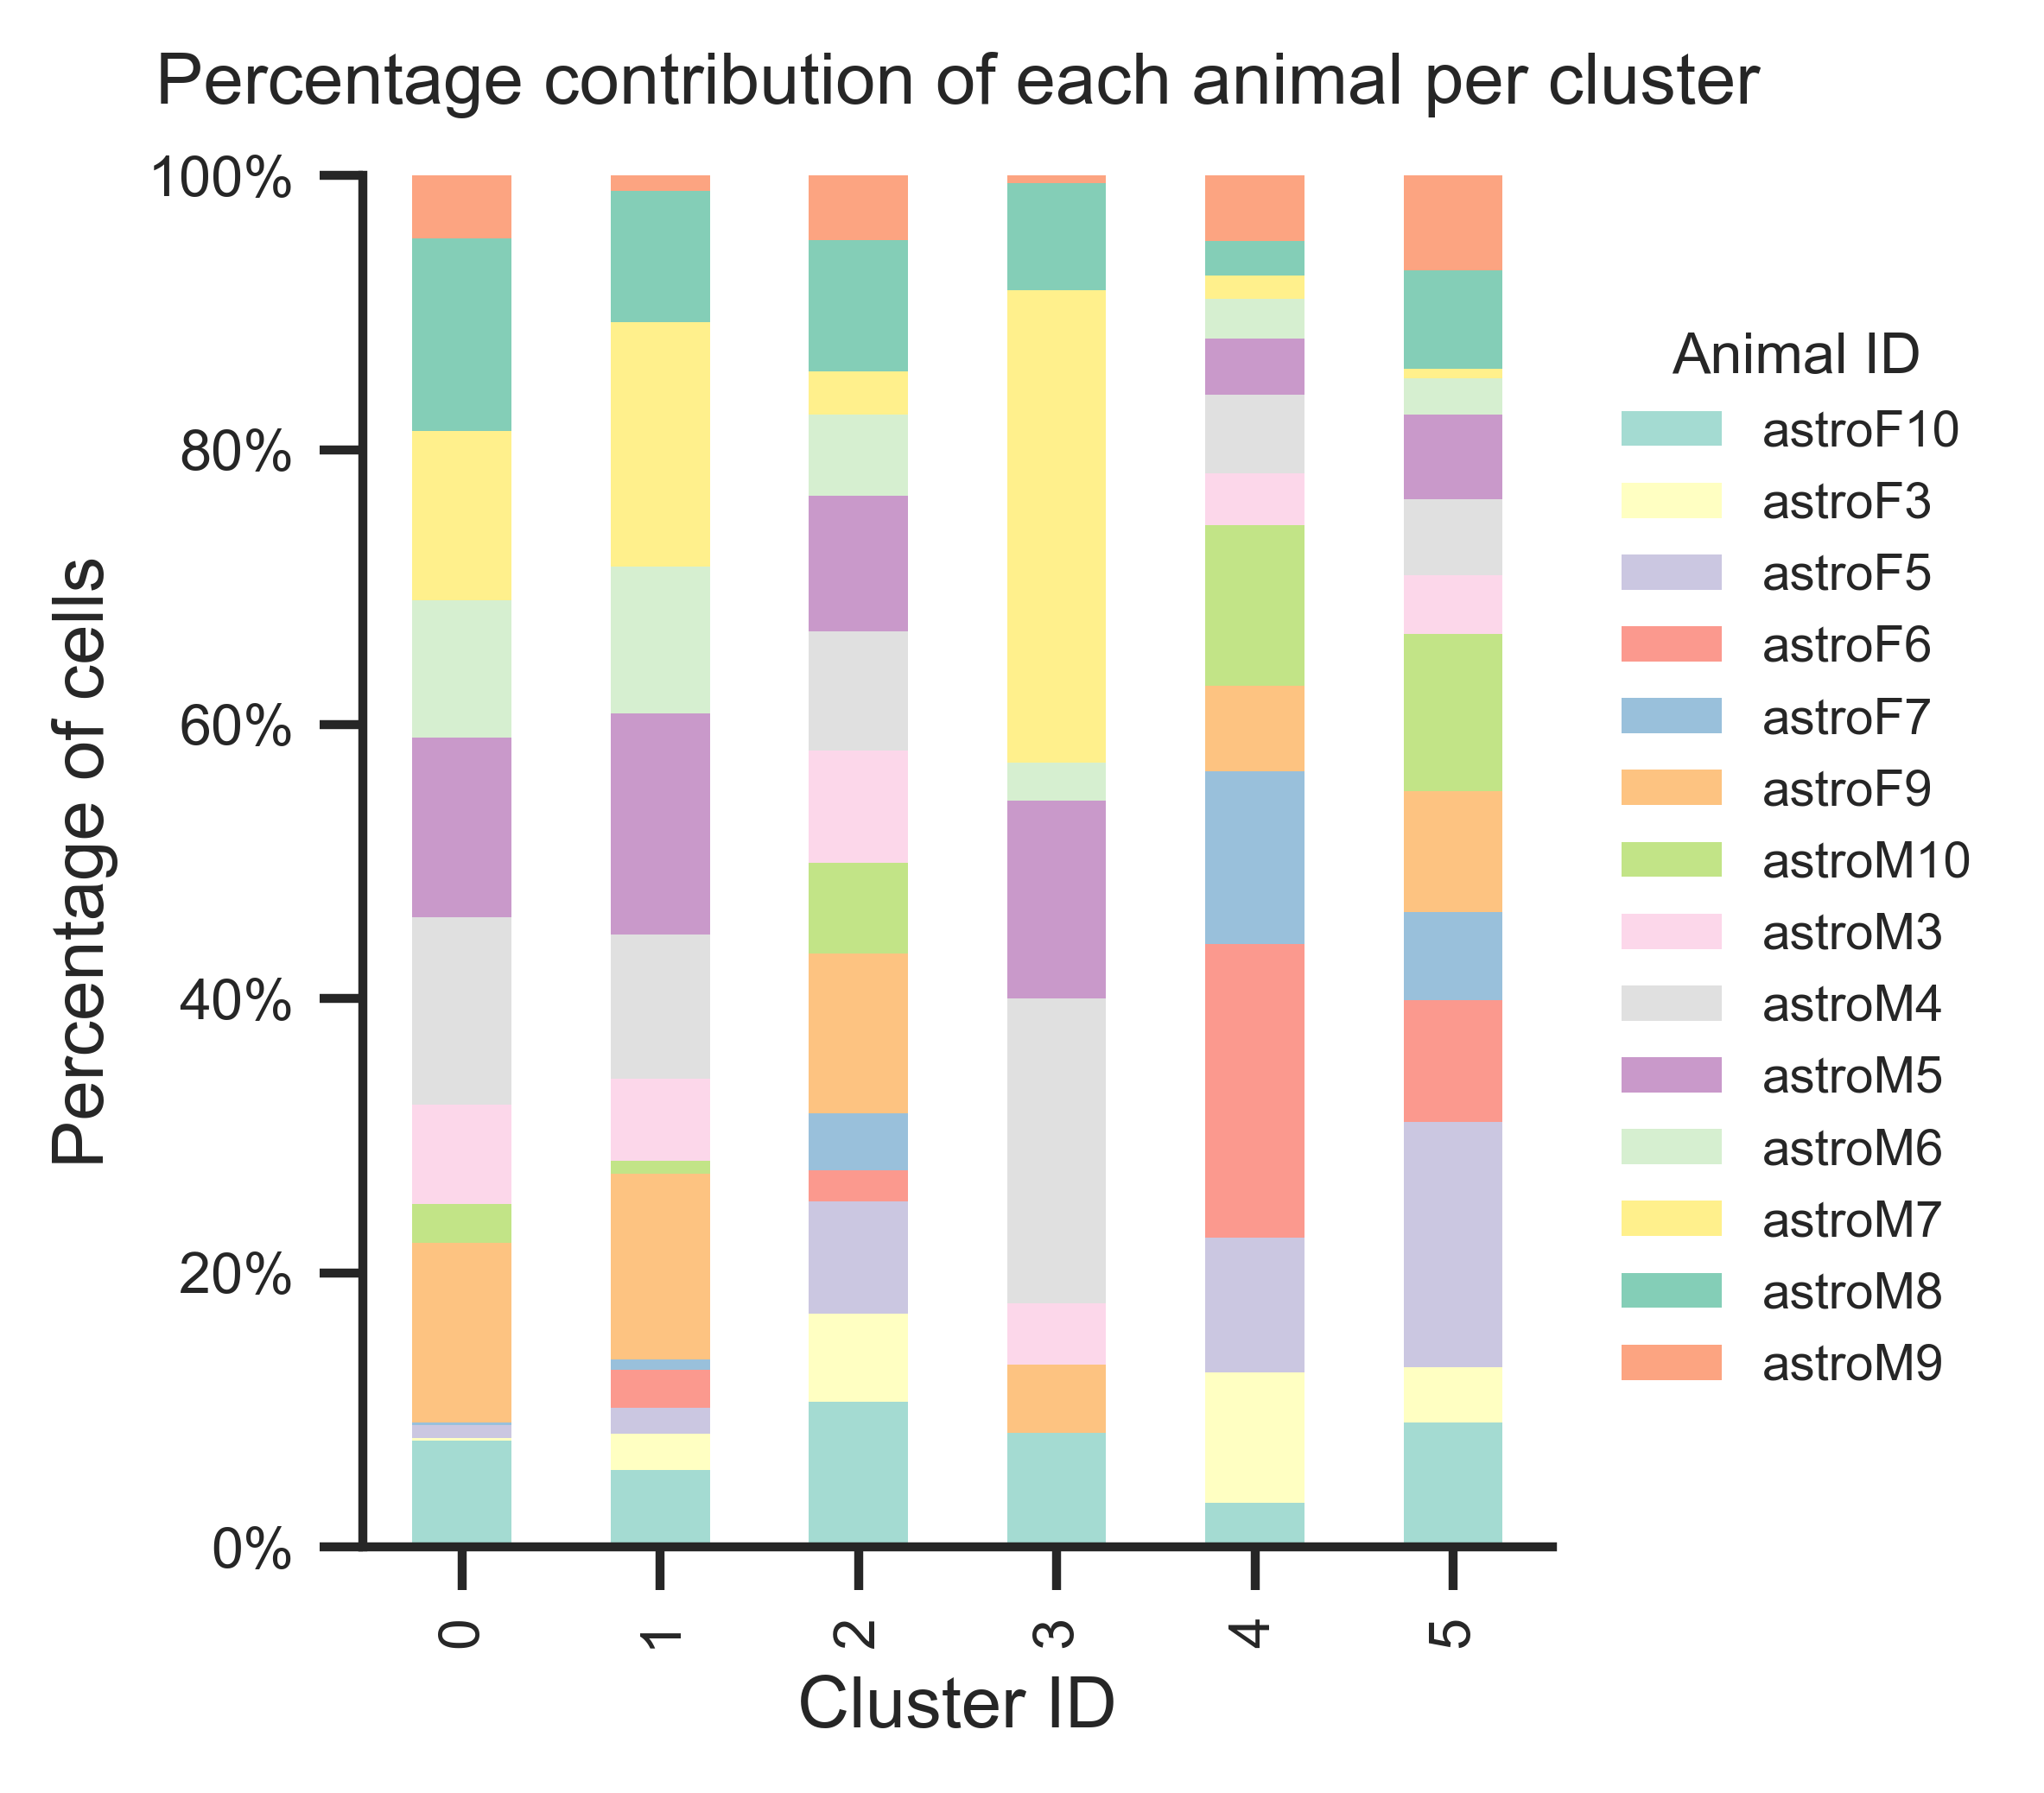

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# --- Formatting (match your style) ---
sns.set(style="ticks", font="Arial")
plt.rcParams.update({'font.size': 8})

# Color map: Set3 (12) + Set2 (3) = 15 colors
colors = sns.color_palette("Set3", 12) + sns.color_palette("Set2", 2)

# Data prep
clusters = np.unique(data['cluster_id'])
animals = np.unique(data['animal_id'])

p_cluster_animal = []
for cluster in clusters:
    df_cluster = data.loc[data['cluster_id'] == cluster]
    total = df_cluster.shape[0]
    percent_animal = [
        np.round((df_cluster.loc[df_cluster['animal_id'] == ani].shape[0] / total) * 100, 2)
        for ani in animals
    ]
    p_cluster_animal.append(percent_animal)

df_percent = pd.DataFrame(p_cluster_animal, columns=animals, index=clusters)

# Use as many colors as animals (preserves your chosen colormap order)
palette = colors[:len(animals)]
sns.set_palette(sns.color_palette(palette))

# --- Plot ---
fig, ax = plt.subplots(figsize=(4, 3.5), dpi=600)

# Stacked bar with your palette & styling
ax = df_percent.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=palette,
    alpha=0.8,         # similar to your bar transparency
    edgecolor='none'   # clean stacks
)

# Labels, title, ticks
ax.set_ylabel("Percentage of cells", fontsize=10)
ax.set_xlabel("Cluster ID", fontsize=10)
ax.set_title("Percentage contribution of each animal per cluster", fontsize=10, pad=10)
ax.tick_params(labelsize=8)

# Percent axis formatting and limits
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

# Legend: move to the right side outside the plot
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    title="Animal ID",
    loc="center left",            # anchor on the left side of the legend box
    bbox_to_anchor=(1.02, 0.5),   # (x, y) — push outside right edge, centered vertically
    fontsize=7,
    title_fontsize=8,
    frameon=False
)


# No grid, despine like Seaborn "ticks" style
ax.grid(False)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Supp_Figures/WaveMap_Supplemental/withoutF8/revision_cfc_allmice_zscored_umap_30_0.1_percentclusterbar.svg')

plt.show()


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def _parse_waveform(s: str) -> np.ndarray:
    s = s.strip()
    if s and s[0] == '[' and s[-1] == ']':
        s = s[1:-1]
    return np.fromstring(s, sep=' ')

def clusters_from_umap(umap_df: pd.DataFrame,
                       cluster_col="cluster_id",
                       waveform_col="waveform"):
    clusters = {}
    for cid, grp in umap_df.groupby(cluster_col):
        waves = [ _parse_waveform(s) for s in grp[waveform_col].dropna().tolist() ]
        waves = [ w for w in waves if w.size ]
        if not waves:
            continue
        m = min(len(w) for w in waves)          # shortest length
        waves = [ w[:m] for w in waves ]        # truncate silently
        clusters[int(cid)] = np.vstack(waves)
    return clusters

def eta_mean_ci_raw(data, ci='tci', sig_duration=10, t_start=-7.5, t_end=15.0):
    n_traces, n_time = data.shape
    time = np.linspace(t_start, t_end, n_time)

    mean_trace = data.mean(axis=0)

    if ci == 'tci':
        c_lo, c_hi = onep.tci(data)
    elif ci == 'bci':
        c_lo, c_hi = onep.bci(data, num_samples=1000)

    sig_starts = onep.eta_significance(c_lo, sig_duration=sig_duration)
    return time, mean_trace, (c_lo, c_hi), sig_starts

def _apply_shock_aesthetics(ax, title="", ylabel="ΔF/F", font="Arial"):
    ax.axvline(x=0, color='black', linestyle='--')
    #ax.text(0, ax.get_ylim()[1] * 1.02, 'Shock Onset', ha='center', va='bottom', fontsize=8, fontname=font)
    ax.set_ylabel(ylabel, fontsize=10, fontname=font, labelpad=15)
    ax.set_xlabel('Time (s)', fontsize=10, fontname=font)
    ax.tick_params(labelsize=8)
    ax.set_title(title, fontsize=10, pad=10, fontname=font)
    sns.despine(ax=ax)

def plot_umap_clusters_overlay(
    umap_df: pd.DataFrame,
    cluster_col="cluster_id",
    waveform_col="waveform",
    ci='tci',
    sig_duration=10,
    t_start=-7.5, t_end=15.0,
    title=None,
    palette=None,
    scale=1.0,
    save_path=None
):
    plt.rcParams.update({'font.size': 8})
    sns.set(style="ticks", font="Arial")

    clusters = clusters_from_umap(umap_df, cluster_col, waveform_col)
    fig, ax = plt.subplots(figsize=(4, 3.5), dpi=600)

    handles, labels = [], []
    for i, cid in enumerate(sorted(clusters.keys())):
        data = clusters[cid] * scale
        t, m, (lo, hi), sig_starts = eta_mean_ci_raw(data, ci=ci, sig_duration=sig_duration,
                                                     t_start=t_start, t_end=t_end)
        color = (palette[i % len(palette)]) if palette else None
        ln, = ax.plot(t, m, lw=1.2, color=color)
        ax.fill_between(t, lo, hi, alpha=0.25, color=ln.get_color())

        y_top = ax.get_ylim()[1] * 0.97
        for s in sig_starts:
            e = min(s + sig_duration, len(t) - 1)
            ax.hlines(y=y_top, xmin=t[s], xmax=t[e], color='black', linewidth=1)

        handles.append(ln); labels.append(f"Cluster {cid}")

    _apply_shock_aesthetics(ax, title=title, ylabel="ΔF/F (z)")
    if handles:
        ax.legend(handles, labels, frameon=False, loc="upper right", fontsize=6)

    plt.tight_layout(pad=3)
    if save_path:
        fmt = save_path.split('.')[-1]
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format=fmt)
    plt.show()
    return ax

# ---------- FACETS: one subplot per cluster ----------
def plot_umap_clusters_facets(
    umap_df: pd.DataFrame,
    cluster_col="cluster_id",
    waveform_col="waveform",
    ci='tci',
    sig_duration=None,
    t_start=-7.5, t_end=15.0,
    title=None,
    palette=None,
    scale=1.0,
    save_path=None
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.rcParams.update({'font.size': 8})
    sns.set(style="ticks", font="Arial")

    clusters = clusters_from_umap(umap_df, cluster_col, waveform_col)
    keys = sorted(clusters.keys())
    n = len(keys)

    # Grid layout: 3 columns per row
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    # Each subplot is 3.5x3.5 inches
    fig, axs = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 3.5, nrows * 3.5),
        dpi=600,
        sharex=True
    )

    axs = np.array(axs).reshape(nrows, ncols)

    for i, cid in enumerate(keys):
        r, c = divmod(i, ncols)
        ax = axs[r, c]
        data = clusters[cid] * scale

        t, m, (lo, hi), sig_starts = eta_mean_ci_raw(
            data, ci=ci, sig_duration=sig_duration,
            t_start=t_start, t_end=t_end
        )

        color = (palette[i % len(palette)]) if palette else None
        ln, = ax.plot(t, m, lw=1.2, color=color)
        ax.fill_between(t, lo, hi, alpha=0.25, color=ln.get_color())

        y_top = ax.get_ylim()[1] * 0.97
        for s in sig_starts:
            e = min(s + sig_duration, len(t) - 1)
            ax.hlines(y=y_top, xmin=t[s], xmax=t[e], color='black', linewidth=1)

        _apply_shock_aesthetics(
            ax,
            title=f"Cluster {cid} (n={data.shape[0]})",
            ylabel="ΔF/F (z)"
        )

    # Turn off unused subplots (if n < nrows*ncols)
    for j in range(i + 1, nrows * ncols):
        r, c = divmod(j, ncols)
        axs[r, c].axis("off")

    fig.suptitle(title, fontsize=10, y=0.995, fontname='Arial')
    plt.tight_layout(pad=3)

    if save_path:
        fmt = save_path.split('.')[-1]
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format=fmt)

    plt.show()
    return axs


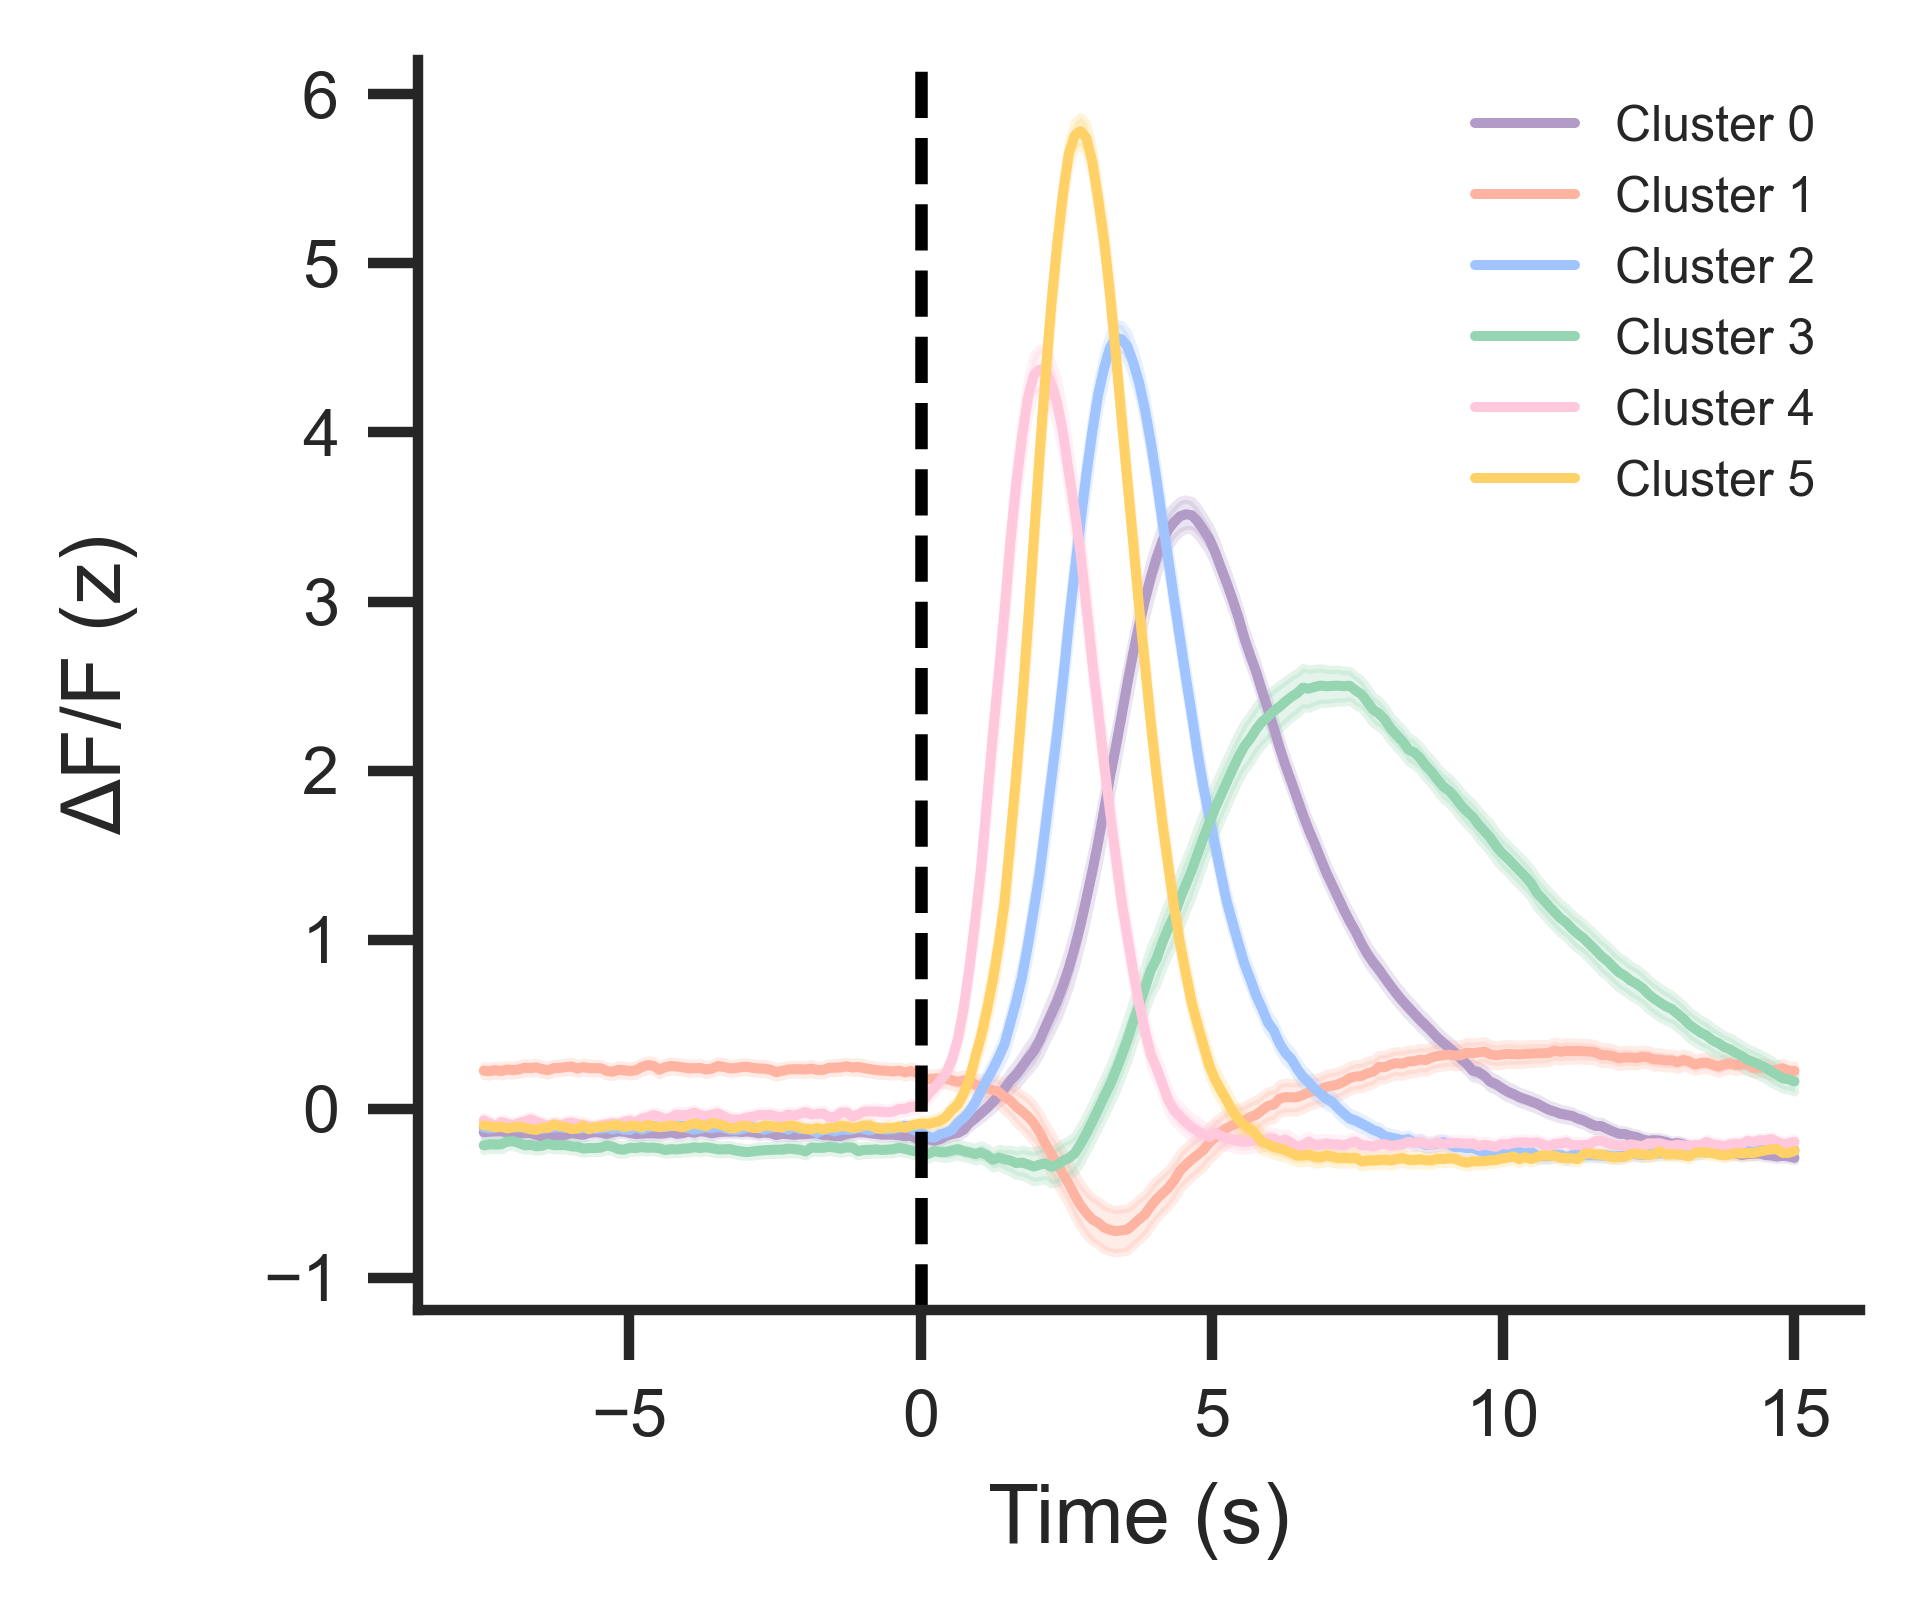

<Axes: xlabel='Time (s)', ylabel='ΔF/F (z)'>

In [21]:
# overlay, tCI, show percent (×100), custom palette
PALETTE = ["#B39BC8", "#FFB4A2", "#A0C4FF", "#95D5B2", "#FFC8DD", "#FFD166"]
import onep
plot_umap_clusters_overlay(
    umap_df,
    ci="tci",
    sig_duration=None,
    palette=PALETTE,
    scale=1.0,
    title=None,
    save_path = '/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Supp_Figures/WaveMap_Supplemental/withoutF8/shock_eta_all_cluster_30_0.1.svg'
)

# facets, bCI, raw ΔF/F units
# plot_umap_clusters_facets(
#     umap_df,
#     ci="bci",
#     sig_duration=None,
#     palette=PALETTE,
#     scale=1.0,
#     title=None,
#     save_path = '/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Supp_Figures/WaveMap_Supplemental/withoutF8/shock_eta_each_cluster_30_0.1.svg'
# )


In [16]:
def plot_umap_clusters_examples(
    umap_df: pd.DataFrame,
    cluster_col="cluster_id",
    waveform_col="waveform",
    n_examples=10,
    trace_range=None,          # NEW: tuple (start, end) for deterministic subset
    t_start=-7.5, t_end=15.0,
    title=None,
    palette=None,
    scale=1.0,
    linewidth=0.8,
    alpha=0.7,
    random_state=0,
    stacked=False,
    offset_step=1.0,
    save_path=None
):
    """
    Plot up to `n_examples` raw traces for each cluster (faceted layout).

    Parameters
    ----------
    trace_range : tuple (start, end) or None
        If provided, selects traces [start:end] instead of random subset.
        Example: trace_range=(0, 10) → plots the first 10 traces per cluster.
    stacked : bool
        If True, vertically offset each trace for clarity.
    offset_step : float
        Vertical offset spacing for stacked traces.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    rng = np.random.RandomState(random_state)

    plt.rcParams.update({'font.size': 8})
    sns.set(style="ticks", font="Arial")

    clusters = clusters_from_umap(umap_df, cluster_col, waveform_col)
    keys = sorted(clusters.keys())
    n = len(keys)

    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 3.5, nrows * 3.5),
        dpi=600,
        sharex=True
    )
    axs = np.array(axs).reshape(nrows, ncols)

    for i, cid in enumerate(keys):
        r, c = divmod(i, ncols)
        ax = axs[r, c]

        data = clusters[cid] * scale
        n_traces, n_time = data.shape
        t = np.linspace(t_start, t_end, n_time)

        # --- choose which traces to show ---
        if trace_range is not None:
            start, end = trace_range
            start = max(0, start)
            end = min(n_traces, end)
            idx = np.arange(start, end)
        else:
            if n_traces <= n_examples:
                idx = np.arange(n_traces)
            else:
                idx = rng.choice(n_traces, n_examples, replace=False)

        subset = data[idx]
        color = (palette[i % len(palette)]) if palette else "gray"

        # --- apply stacking ---
        offsets = np.arange(len(subset)) * offset_step if stacked else np.zeros(len(subset))

        for j, y in enumerate(subset):
            ax.plot(t, y + offsets[j], lw=linewidth, alpha=alpha, color=color)

        if stacked:
            ax.set_yticks([])
            ax.set_ylabel("ΔF/F (Z)")
        else:
            _apply_shock_aesthetics(ax, ylabel="ΔF/F (Z)")

        ax.set_title(f"Cluster {cid} (showing {len(idx)} of {n_traces})", fontsize=8)

    # turn off unused panels
    for j in range(i + 1, nrows * ncols):
        r, c = divmod(j, ncols)
        axs[r, c].axis("off")

    if title:
        fig.suptitle(title, fontsize=10, y=0.995, fontname='Arial')

    plt.tight_layout(pad=3)
    if save_path:
        fmt = save_path.split('.')[-1]
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format=fmt)
    plt.show()
    return axs


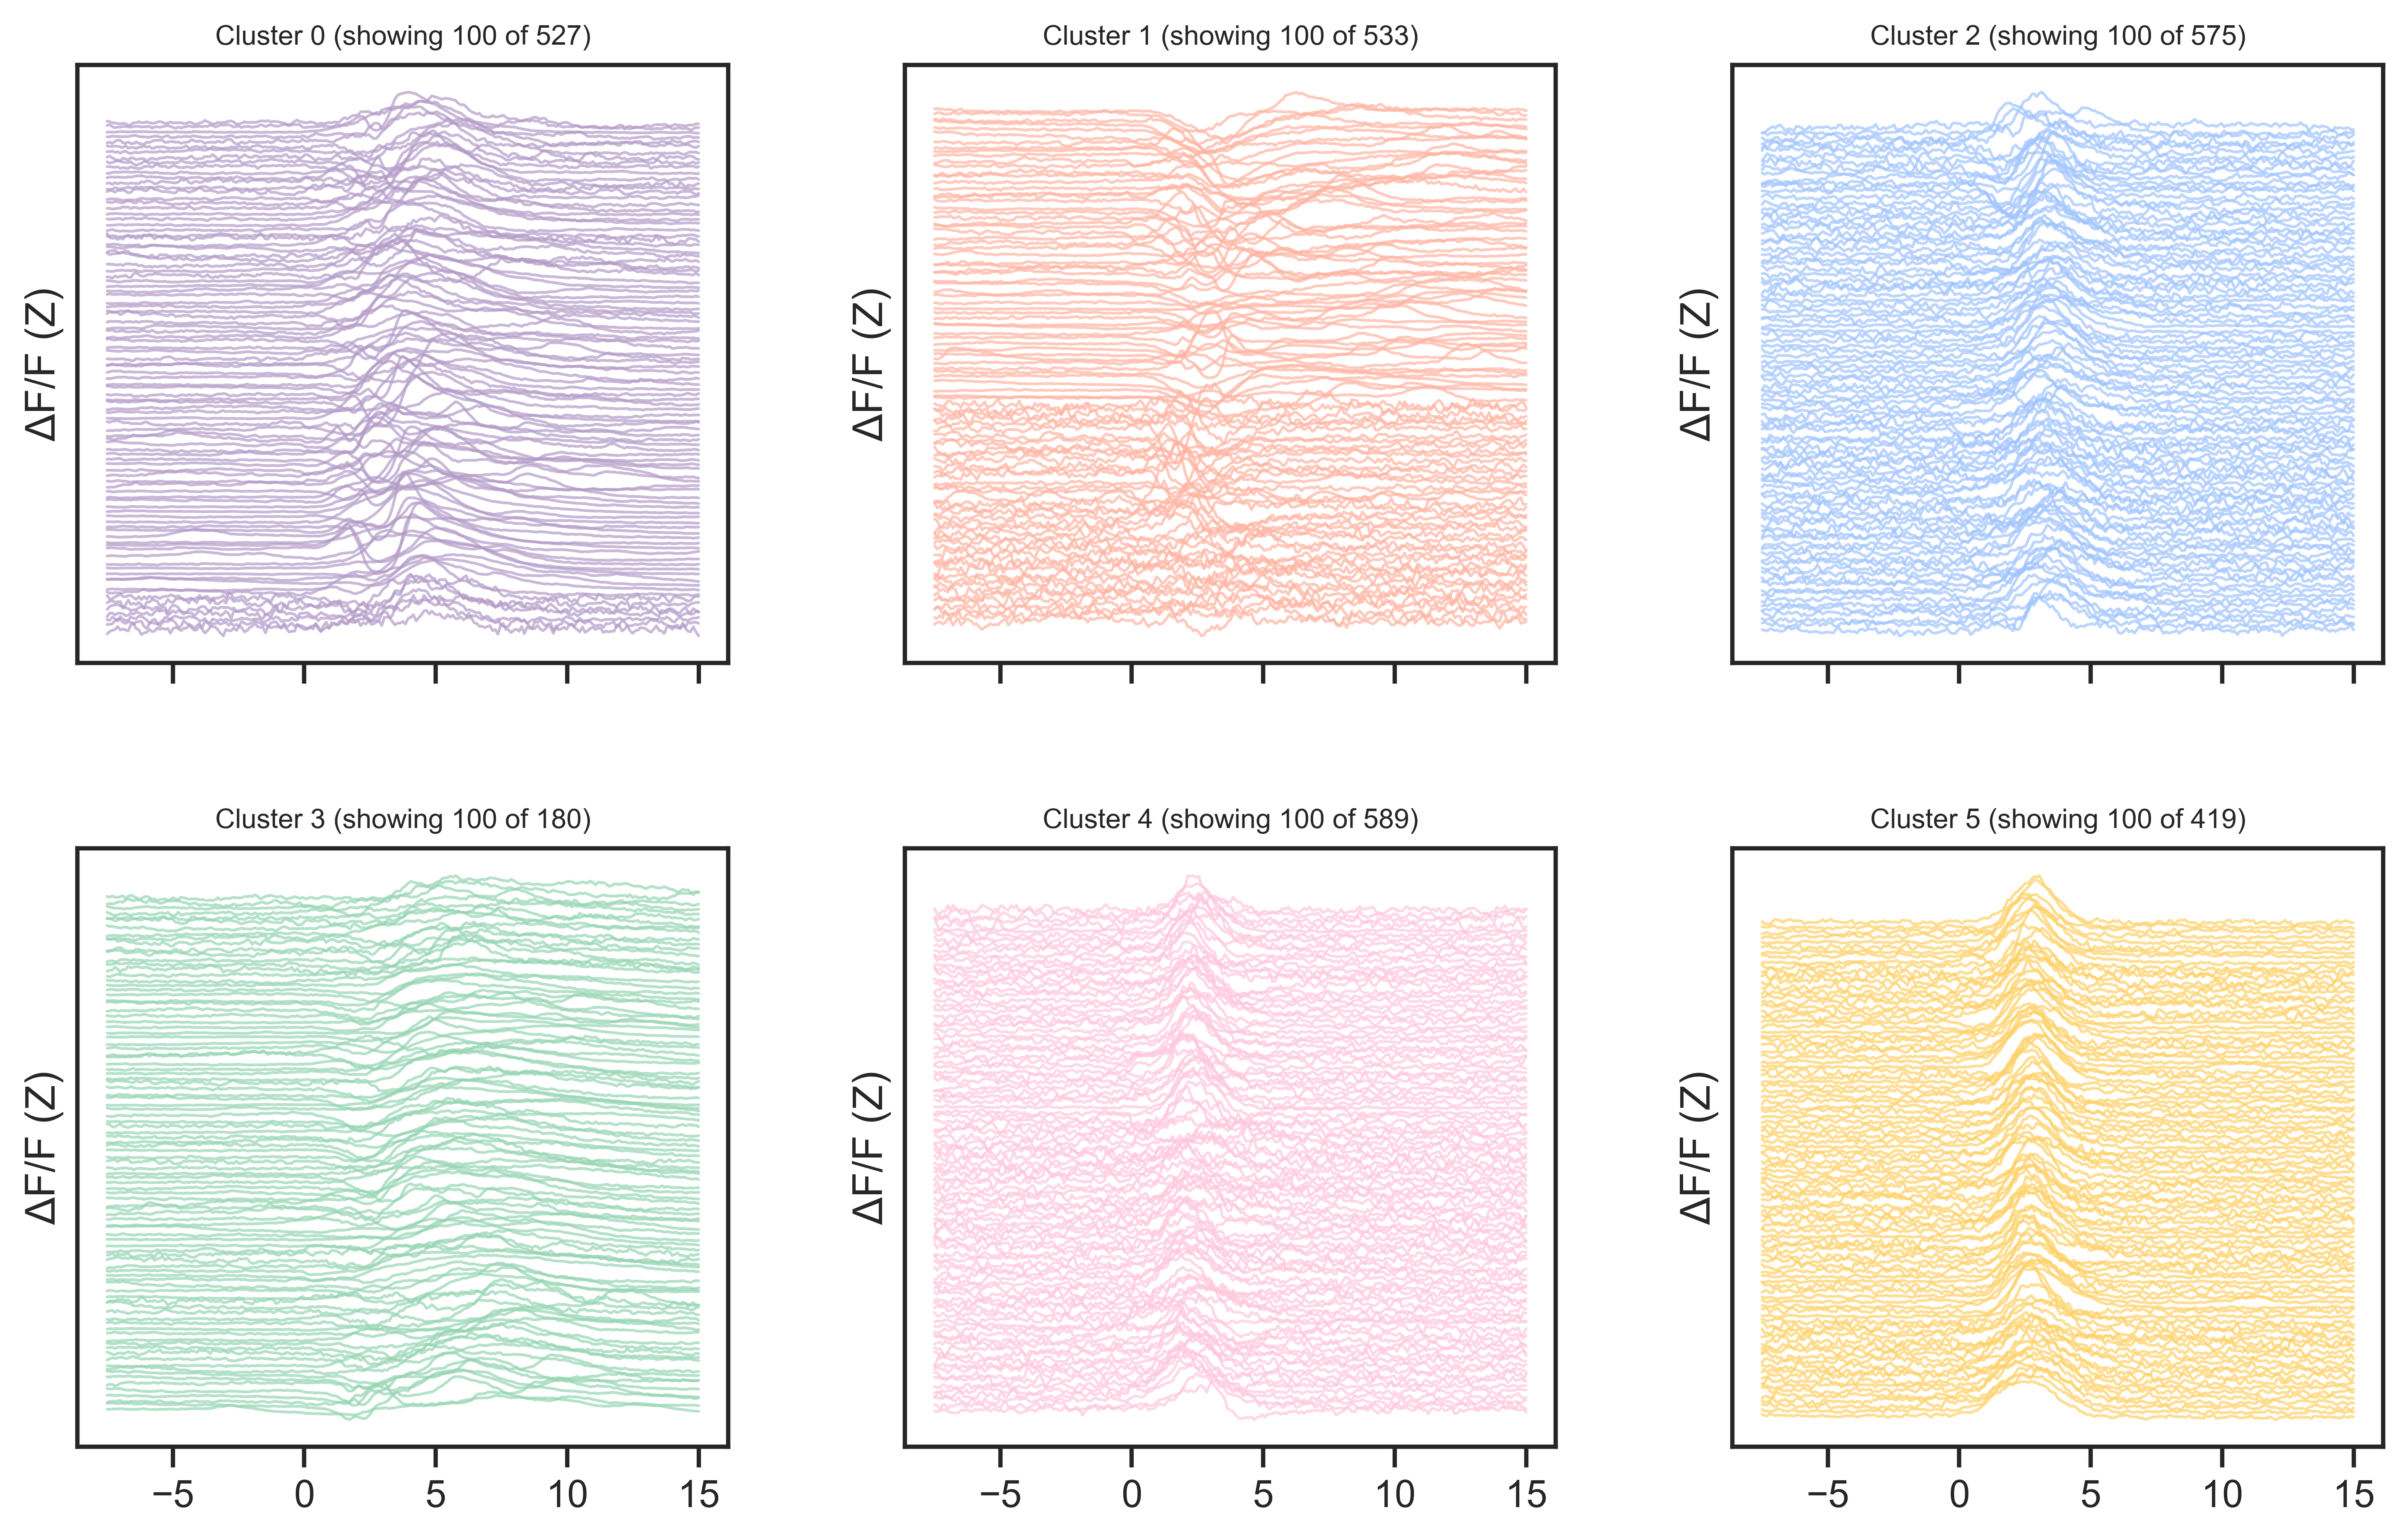

array([[<Axes: title={'center': 'Cluster 0 (showing 100 of 527)'}, ylabel='ΔF/F (Z)'>,
        <Axes: title={'center': 'Cluster 1 (showing 100 of 533)'}, ylabel='ΔF/F (Z)'>,
        <Axes: title={'center': 'Cluster 2 (showing 100 of 575)'}, ylabel='ΔF/F (Z)'>],
       [<Axes: title={'center': 'Cluster 3 (showing 100 of 180)'}, ylabel='ΔF/F (Z)'>,
        <Axes: title={'center': 'Cluster 4 (showing 100 of 589)'}, ylabel='ΔF/F (Z)'>,
        <Axes: title={'center': 'Cluster 5 (showing 100 of 419)'}, ylabel='ΔF/F (Z)'>]],
      dtype=object)

In [20]:
plot_umap_clusters_examples(
    umap_df,
    trace_range=(0, 100),
    stacked=True,
    offset_step=0.8,
    palette=PALETTE,
    save_path='/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Supp_Figures/WaveMap_Supplemental/withoutF8/shock_eta_each_100cells_cluster_30_0.1_CLUSTER3.svg'
)
